In [1]:
from nilearn import datasets
import nibabel as nib
import numpy as np
from neuromaps import nulls, stats
from neuromaps import parcellate
from nilearn.maskers import NiftiLabelsMasker

# Load your wake and sleep group-level t-maps
wake_img = nib.load('/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/task-sleep_contrast-mreyemove_W-clean-with-fd-clamped-original-sleep/second_level_flame/flameo/stats/tstat1.nii.gz')
sleep_img = nib.load('/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/task-sleep_contrast-mreyemove_S-clean-with-fd-clamped-original-sleep/second_level_flame/flameo/stats/tstat1.nii.gz')

# Parcellate using Schaefer atlas (same one you used for FC)
parcellatew = datasets.fetch_atlas_schaefer_2018(n_rois=500).maps
destrieux = parcellate.Parcellater(parcellation, 'fsaverage').fit()
neurosynth_parc = destrieux.transform(neurosynth, 'fsaverage')
abagen_parc = destrieux.transform(abagen, 'fsaverage')

masker = NiftiLabelsMasker(labels_img=parc, standardize=False)
vals_wake = masker.fit_transform(wake_img).squeeze()   # (500,)
vals_sleep = masker.fit_transform(sleep_img).squeeze()

# Generate spatial-autocorrelation-preserving null maps for wake
null_maps = nulls.burt2020(
  vals_wake,
  atlas='mni152',
  density='2mm',
  parcellation=parc,
  n_perm=5,
  seed=42,
  n_proc=6,
)

# Compare: observed r + p-value against null
corr, pval = stats.compare_images(vals_wake, vals_sleep, nulls=null_maps)
print(f'r = {corr:.3f}, p_spin = {pval:.4f}')


/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


[fetch_atlas_schaefer_2018] Dataset found in /Users/zach/nilearn_data/schaefer_2018


KeyboardInterrupt: 

In [7]:
from SleepMReye.sleepmreye.extract_eog import extract_eog
from pathlib import Path
import mne

subject = "17"
run = 3
eeg_dir = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/amri_eegfmri")

# path = Path("/Users/zach/2025_RA/matthias/sleepMReye/eeg/sub-09/sub-09_task-rest_run-1_eeg.vhdr")
# path = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/amri_eegfmri/sub-04/sub-04_task-sleep_run-2_eeg_desc-gacbcg_eeg.set")
# raw = mne.io.read_raw_eeglab(str(path), preload=True)
raw = extract_eog(eeg_dir, subject, run)

Reading /Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/amri_eegfmri/sub-17/sub-17_task-sleep_run-3_eeg_desc-gacbcg_eeg.fdt
Reading 0 ... 238239  =      0.000 ...   952.956 secs...
Filtering raw data in 1 contiguous segment

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal allpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Filter length: 1 samples (0.004 s)


/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/extract_eog.py:22: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(path), preload=True)


In [8]:
import numpy as np
annotation = "R128"

events, event_ids = mne.events_from_annotations(raw)
r128_id = {annotation: event_ids[annotation]}
r128_events = events[events[:, 2] == r128_id[annotation]]


button_tap_annot = "S  1"
if button_tap_annot not in event_ids:
    tap_counts = np.zeros(shape=(len(r128_events[:, 0])))
    print(tap_counts)
# s1_id = {annotation: event_ids[annotation]}
# s1_events = events[events[:, 2] == s1_id[annotation]]

# new_event_id = 999
# sfreq = raw.info['sfreq']
# 
# onsets = r128_events[:, 0]
# win_len = np.median(np.diff(onsets))
# shifted_onsets = onsets
# tmax = win_len / sfreq
# 
# # Build synthetic events at shifted onsets
# samples = shifted_onsets.astype(int)
# events_shifted = np.c_[samples,
#                        np.zeros_like(samples),
#                        np.full_like(samples, new_event_id, dtype=int)]
# 
# picks = mne.pick_types(raw.info, meg=False, eeg=False, stim=False, eog=True)
# 
# epochs = mne.Epochs(
#     raw,
#     events_shifted,
#     event_id=new_event_id,
#     tmin=0.0,
#     tmax=tmax,
#     picks=picks,
#     baseline=None,
#     preload=True
# )

Used Annotations descriptions: ['R', 'R128', 'S  1', 'S  2', 'S  3', 'Sync On', 'boundary']


Used Annotations descriptions: ['R', 'R128', 'S  1', 'S  2', 'S  3', 'Sync On', 'boundary']
Not setting metadata
429 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 429 events and 525 original time points ...
0 bad epochs dropped
Used Annotations descriptions: ['R', 'R128', 'S  1', 'S  2', 'S  3', 'Sync On', 'boundary']
Not setting metadata
429 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 429 events and 526 original time points ...
0 bad epochs dropped


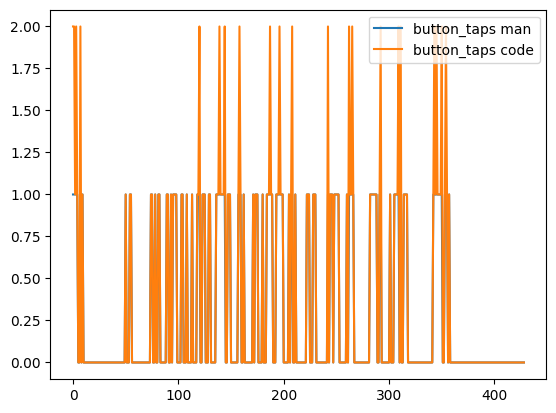

In [10]:
from SleepMReye.sleepmreye.extract_eog import extract_TR_epochs
import numpy as np 

annotation = "R128"

events, event_ids = mne.events_from_annotations(raw)
r128_code = event_ids[annotation]
r128_events = events[events[:, 2] == r128_code]

sfreq = raw.info['sfreq']
win_len = int(np.median(np.diff(r128_events[:, 0])))
tmax = (win_len - 1) / sfreq
picks = ["EOG"]
epochs = mne.Epochs(
    raw, r128_events, event_id={annotation: r128_code},
    tmin=0.0, tmax=tmax,
    baseline=None,
    preload=True,
    picks=picks,
)

other_annotation = "S  1"
other_code = event_ids[other_annotation]
other_samples = events[events[:, 2] == other_code, 0]

# Window length in samples (same one you used for tmax)
counts = np.array([
    np.sum((other_samples >= s) & (other_samples < s + win_len))
    for s in r128_events[:, 0]
])

# counts

plt.plot(counts > 0, label="button_taps man")
df = mrio.events
# plt.plot(df[(df["subject"] == subject) & (df["run"] == run)]["S"].reset_index(drop=True), label="In Sleep")# 
epochs_orig, taps  = extract_TR_epochs(raw, picks=['EOG'])

plt.plot(taps, label="button_taps code")
# 
# signal = []
# for epoch in epochs:
#     signal.append(np.mean(epoch))
# 
# 
# orig_signal = []
# for epoch in epochs_orig:
#     orig_signal.append(np.mean(epoch))
#     
# from matplotlib import pyplot as plt 
# 
# plt.plot(signal, label='signal')
# plt.plot(orig_signal, label='signal orig')
plt.legend()

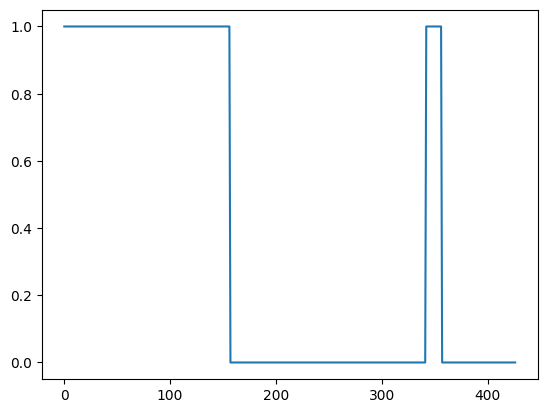

In [50]:
plt.plot(df[(df["subject"] == subject) & (df["run"] == run)]["W"].reset_index(drop=True))

In [1]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    # exclude_subjects=["01", "02", "12", "21", "07", "11", "13", "31"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    # load_eog=False,
    desc_add="clean",
    ignore_boundary_trs=0
)

eog_df = mrio.load_eog_df()

EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


In [7]:

subject = "18"
run = 3
eog_run_df = eog_df[
                    (eog_df["subject"] == subject) & (eog_df["run"] == str(run))
                ].reset_index(drop=True)

# eog_run_df
df = mrio.events
run_df = df[(df["subject"] == subject) & (df["run"] == run)
                ].reset_index(drop=True)
# (run_df["button_tap_count"] == 
# eog_run_df["button_tap_count"]
sum(run_df["button_tap_count"] > 0)

0

In [20]:
import numpy as np
import pandas as pd

# df = pd.read_pickle("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/eeg/mean_eog_reg.p")
# df

df = pd.read_pickle("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/eeg/mean_eog_reg.p")
eog_data = df
subject = "10"
run = 1
eog_run_df = eog_data[
                    (eog_data["subject"] == subject) & (eog_data["run"] == run)
                ].reset_index(drop=True)
eog_run = eog_run_df["signal"].to_numpy()
eog_run


array([], dtype=float64)

In [4]:
A = np.abs(np.diff((X - Y)))
B = np.diff(np.abs((X - Y)))
np.all(A == B)

False

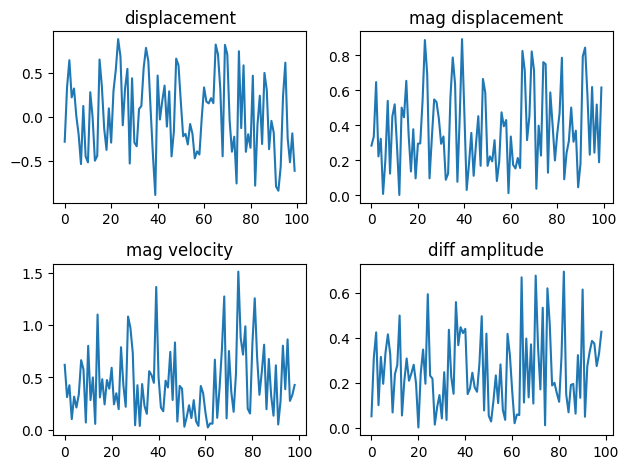

In [16]:
from matplotlib import pyplot as plt

f, axs = plt.subplots(nrows=2, ncols=2)
axs[0,0].plot(X-Y)
axs[0,0].set_title('displacement')

axs[0,1].plot(np.abs(X-Y))
axs[0,1].set_title('mag displacement')

axs[1,0].plot(np.abs(np.diff(X-Y)))
axs[1,0].set_title('mag velocity')


axs[1,1].plot(np.abs(np.diff(np.abs(X-Y))))
axs[1,1].set_title('diff amplitude')
plt.tight_layout()

In [32]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    ignore_boundary_trs=0
)

# for subj, run, run_df in mrio.iter_run_events():
#     continue

EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


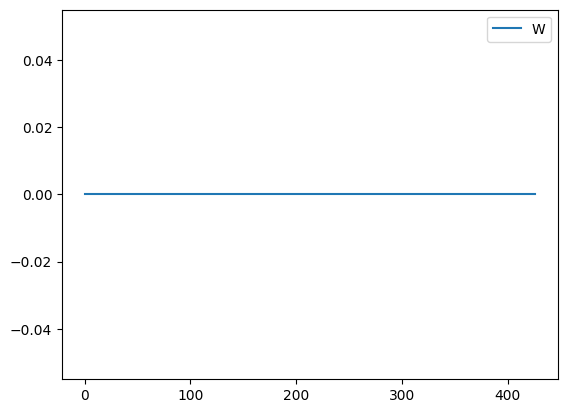

In [2]:
from matplotlib import pyplot as plt
subject = "17"
run = 3

df = mrio.events[(mrio.events["subject"]==subject) & (mrio.events["run"]==run)].reset_index(drop=True)
plt.plot(df["button_tap_count"], label="W")
# plt.plot(df["mreyemove_S"], label="S")
# plt.plot(df["mreyemove_trans"], color="r", label="trans")
plt.legend()

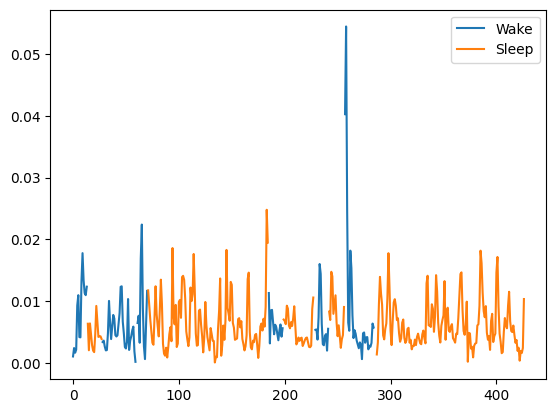

In [36]:
from matplotlib import pyplot as plt
subject = "17"
run = 3

df = mrio.events[(mrio.events["subject"]==subject) & (mrio.events["run"]==run)].reset_index(drop=True)
wake = df["mreyemove_W"].values
wake[wake==0] = np.nan

sleep = df["mreyemove_S"].values
sleep[sleep==0] = np.nan

plt.plot(wake, label="Wake")
plt.plot(sleep, label="Sleep")
plt.legend()

In [4]:
subject_fd_means = {}
for subject, run, run_df in mrio.iter_run_events(run_exclusion=False): 
    df = mrio.load_confounds(subject=subject, run=run, confound_names=["framewise_displacement"])
    subject_fd_means.setdefault(subject, []).append(df["framewise_displacement"].mean())
    

Skipping subject 01 with too few runs 3
Skipping subject 12 with too few runs 3


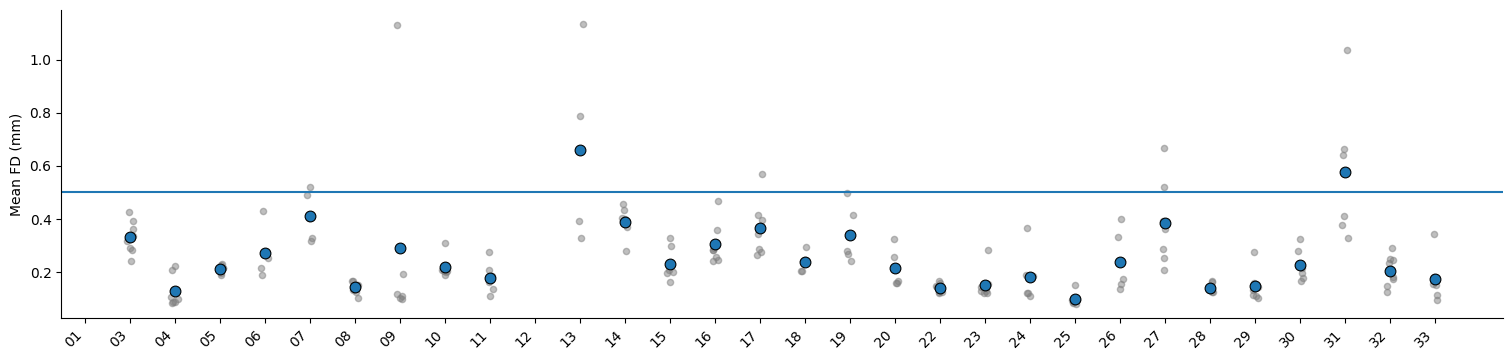

In [5]:

from matplotlib import pyplot as plt
import numpy as np 

data = subject_fd_means
jitter=0.08
fig, ax = plt.subplots(figsize=(max(4, 0.6 * len(data)), 4))

subjects = list(data.keys())

for i, subj in enumerate(subjects):
    vals = np.asarray(data[subj], dtype=float)
    if len(vals) < 4:
        print(f"Skipping subject {subj} with too few runs {len(vals)}")
        continue
    x = i + np.random.uniform(-jitter, jitter, size=vals.size)
    ax.scatter(x, vals, alpha=0.5, color='gray', s=20, zorder=1)
    ax.scatter(i, vals.mean(), color='C0', s=60, zorder=2,
               edgecolor='black', linewidth=0.8)

ax.axhline(0.5)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Mean FD (mm)')
ax.spines[['top', 'right']].set_visible(False)

In [25]:
import scipy 

x = scipy.io.loadmat("/Volumes/NSD/eye_tracking/sub_01_eyedata_preprocessed.mat", simplify_cells=True)

In [32]:
x['data']

# Subject, session, []

[{'samples': array([[1.95387400e+06, 1.09188235e+01, 4.86823529e+00, 1.68600000e+03],
         [1.95387500e+06, 1.09164706e+01, 4.85411765e+00, 1.68400000e+03],
         [1.95387500e+06, 1.09082353e+01, 4.81294118e+00, 1.68400000e+03],
         ...,
         [2.19386600e+06, 1.15423529e+01, 5.56000000e+00, 1.17600000e+03],
         [2.19386600e+06, 1.15058824e+01, 5.56588235e+00, 1.17800000e+03],
         [2.19386700e+06, 1.15011765e+01, 5.59294118e+00, 1.18000000e+03]]),
  'filename': 'eyedata_nsdimagery_run01_samples.asc',
  'messages': {'OnOff': array([1953874, 2193867], dtype=int32),
   'all': array([['**', 'CONVERTED', 'FROM',
           'X:\\Matthias\\NSD\\subj01\\eyedata\\eyedata_nsdimagery_run01.edf'],
          ['using', 'edfapi', '3.1', 'Win32'],
          ['Feb', '16', '2010', 'on'],
          ['Thu', 'May', '13', '15:08:42'],
          ['2021', array([], dtype='<U1'), array([], dtype='<U1'),
           array([], dtype='<U1')],
          ['**', 'DATE:', 'Thu', 'Nov'],
      

In [2]:

from matplotlib import pyplot as plt
import numpy as np 

data = subject_fd_means
jitter=0.08
fig, ax = plt.subplots(figsize=(max(4, 0.6 * len(data)), 4))

subjects = list(data.keys())

for i, subj in enumerate(subjects):
    vals = np.asarray(data[subj], dtype=float)
    if len(vals) < 4:
        print(f"Skipping subject {subj} with too few runs")
        continue
    x = i + np.random.uniform(-jitter, jitter, size=vals.size)
    ax.scatter(x, vals, alpha=0.5, color='gray', s=20, zorder=1)
    ax.scatter(i, vals.mean(), color='C0', s=60, zorder=2,
               edgecolor='black', linewidth=0.8)

ax.axhline(0.5)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Mean FD (mm)')
ax.spines[['top', 'right']].set_visible(False)

NameError: name 'subject_fd_means' is not defined

In [3]:
for subj, vals in subject_fd_means.items():
    if len(vals) < 4:
        print(subj)

07
11
13
31


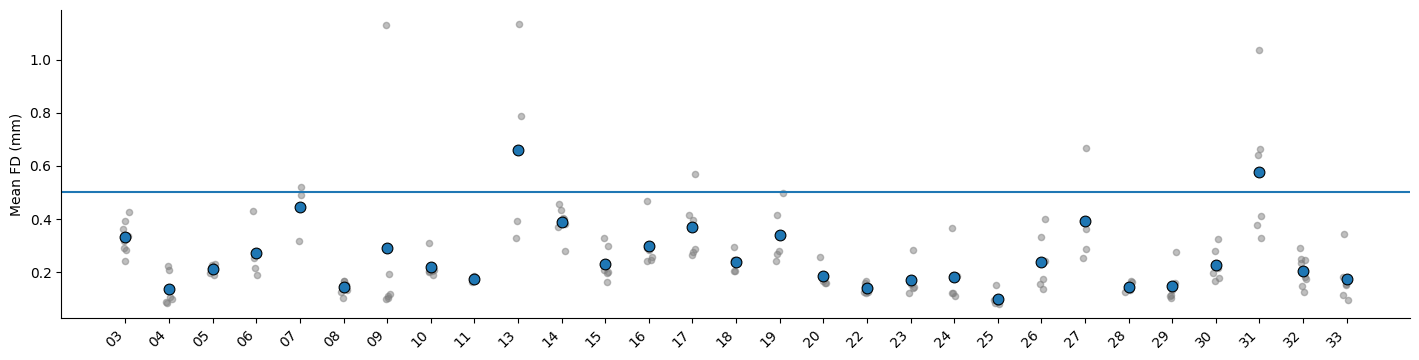

In [27]:
from matplotlib import pyplot as plt
import numpy as np 

data = subject_fd_means
jitter=0.08
fig, ax = plt.subplots(figsize=(max(4, 0.6 * len(data)), 4))

subjects = list(data.keys())
for i, subj in enumerate(subjects):
    vals = np.asarray(data[subj], dtype=float)
    x = i + np.random.uniform(-jitter, jitter, size=vals.size)
    ax.scatter(x, vals, alpha=0.5, color='gray', s=20, zorder=1)
    ax.scatter(i, vals.mean(), color='C0', s=60, zorder=2,
               edgecolor='black', linewidth=0.8)

ax.axhline(0.5)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Mean FD (mm)')
ax.spines[['top', 'right']].set_visible(False)

In [29]:
subject_fd_means["19"]

[0.23981978272380972,
 0.27864347008524626,
 0.2675561458893503,
 0.41467917175498337,
 0.49676878884427195]

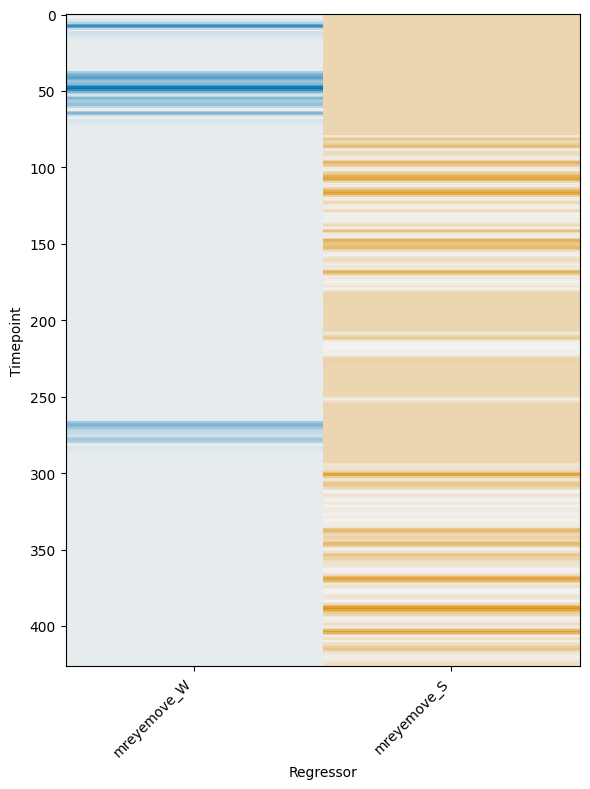

In [6]:
from matplotlib.colors import LinearSegmentedColormap
from mreyemove.analysis.glm.first_level import build_design_matrix
from mreyemove.analysis.glm.cli import construct_desc
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO
from mreyemove.analysis.glm.config import GLMConfig
from nilearn import plotting 
from matplotlib import pyplot as plt
import numpy as np
subject = "17"
run = 3

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
df = mrio.events 
run_events = df[(df["subject"] == subject) & (df["run"] == run)]

X = build_design_matrix(
    dataset=mrio,
    subject=subject,
    run=run,
    run_events=run_events,
    config=config,
)



def make_cmap(hex_color, background="#f2f2f2ff", name=None):
    """White (or other bg) -> hex_color colormap."""
    return LinearSegmentedColormap.from_list(
        name or hex_color, [background, hex_color]
    )


use_abs = True
n_regs = 0

fig, ax = plt.subplots(figsize=(6, 8))
X = X.iloc[:, 0:2+n_regs]
n_tp, n_reg = X.shape
hex_colors = ["#0173b2ff", "#de8f05f2",] + ["#888888"] * (n_reg - 2)
# if hex_colors is None:
#     A, B, then nuisance regressors in grey
    # hex_colors = ["#1f6feb", "#d1242f"] + ["#888888"] * (n_reg - 2)

cmaps = [make_cmap(c) for c in hex_colors]

# cmaps = ["Blues", "Reds"] + ["Greys"] * (n_reg - 2)


for i, (col, cmap) in enumerate(zip(X.columns, cmaps)):
    vals = X[col].values
    data = np.abs(vals) if use_abs else vals
    vmax = np.abs(vals).max() or 1.0  # avoid vmax=0 for empty cols
    ax.imshow(
        data[:, None],
        aspect="auto",
        cmap=cmap,
        vmin=0 if use_abs else -vmax,
        vmax=vmax,
        extent=(i - 0.5, i + 0.5, n_tp - 0.5, -0.5),
        interpolation="nearest",
    )

ax.set_xlim(-0.5, n_reg - 0.5)
ax.set_ylim(n_tp - 0.5, -0.5)
ax.set_xticks(range(n_reg))
ax.set_xticklabels(X.columns, rotation=45, ha="right")
ax.set_xlabel("Regressor")
ax.set_ylabel("Timepoint")
plt.tight_layout()
# X
# plotting.plot_design_matrix(X,rescale=True)

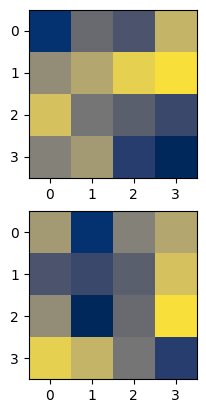

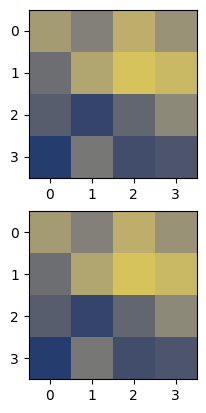

In [30]:
"""
Plot similar and different matrices for the analysis figure 
"""


from scipy.stats import rankdata
from matplotlib import pyplot as plt



def correlated_matrices(rho, size=4, value_range=(0, 1), seed=None):
    """
    Two `size` x `size` matrices with entries bounded in `value_range`
    and flattened Pearson/Spearman correlation near `rho`.

    Construction:
      1. Draw A, noise ~ N(0, 1), standardized.
      2. B = rho * A + sqrt(1 - rho^2) * noise.
      3. Map each matrix to uniform ranks in [0, 1], then scale to range.
         This bounds outputs exactly and preserves rank correlation.
    """
    if not -1 <= rho <= 1:
        raise ValueError("rho must be in [-1, 1].")
    low, high = value_range
    if high <= low:
        raise ValueError("value_range must be (low, high) with high > low.")

    rng = np.random.default_rng(seed)

    def standardize(x):
        return (x - x.mean()) / x.std()

    A = standardize(rng.standard_normal((size, size)))
    noise = standardize(rng.standard_normal((size, size)))
    B = rho * A + np.sqrt(1 - rho**2) * noise

    def to_range(x):
        # Rank-based mapping -> uniform on (0, 1), then rescale.
        # Using (rank - 0.5) / n puts values strictly inside (0, 1).
        n = x.size
        u = (rankdata(x, method="average").reshape(x.shape) - 0.5) / n
        return low + u * (high - low)

    return to_range(A), to_range(B)


# Plot different matrices
r = 0.0001
A, B = correlated_matrices(rho=r, size=4, seed=10, value_range=(-2, 2))

f, axs = plt.subplots(2,1)
vmin = -2
vmax = 2
axs[0].imshow(A, cmap="cividis", vmin=vmin, vmax=vmax)
axs[1].imshow(B, cmap="cividis", vmin=vmin, vmax=vmax)
plt.show()

# Plot similar matrices
r = 1
A, B = correlated_matrices(rho=r, size=4, seed=0, value_range=(-1.5, 1.5))

f, axs = plt.subplots(2,1)
vmin = -2
vmax = 2
axs[0].imshow(A, cmap="cividis", vmin=vmin, vmax=vmax)
axs[1].imshow(B, cmap="cividis", vmin=vmin, vmax=vmax)
plt.show()


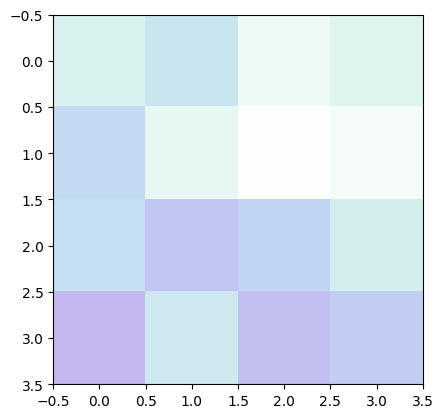

In [72]:
plt.imshow(B,  cmap="cubehelix", vmin=-1, vmax=1)

/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



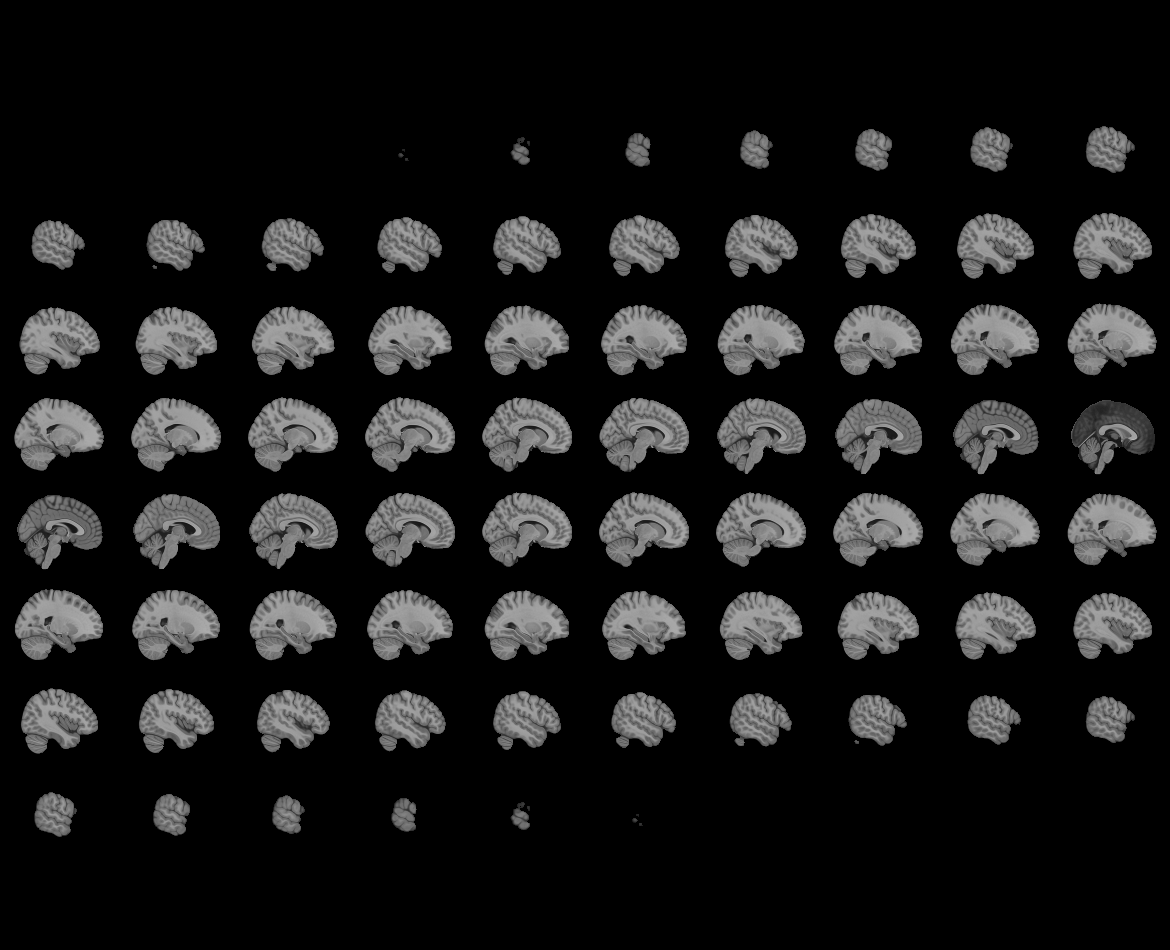
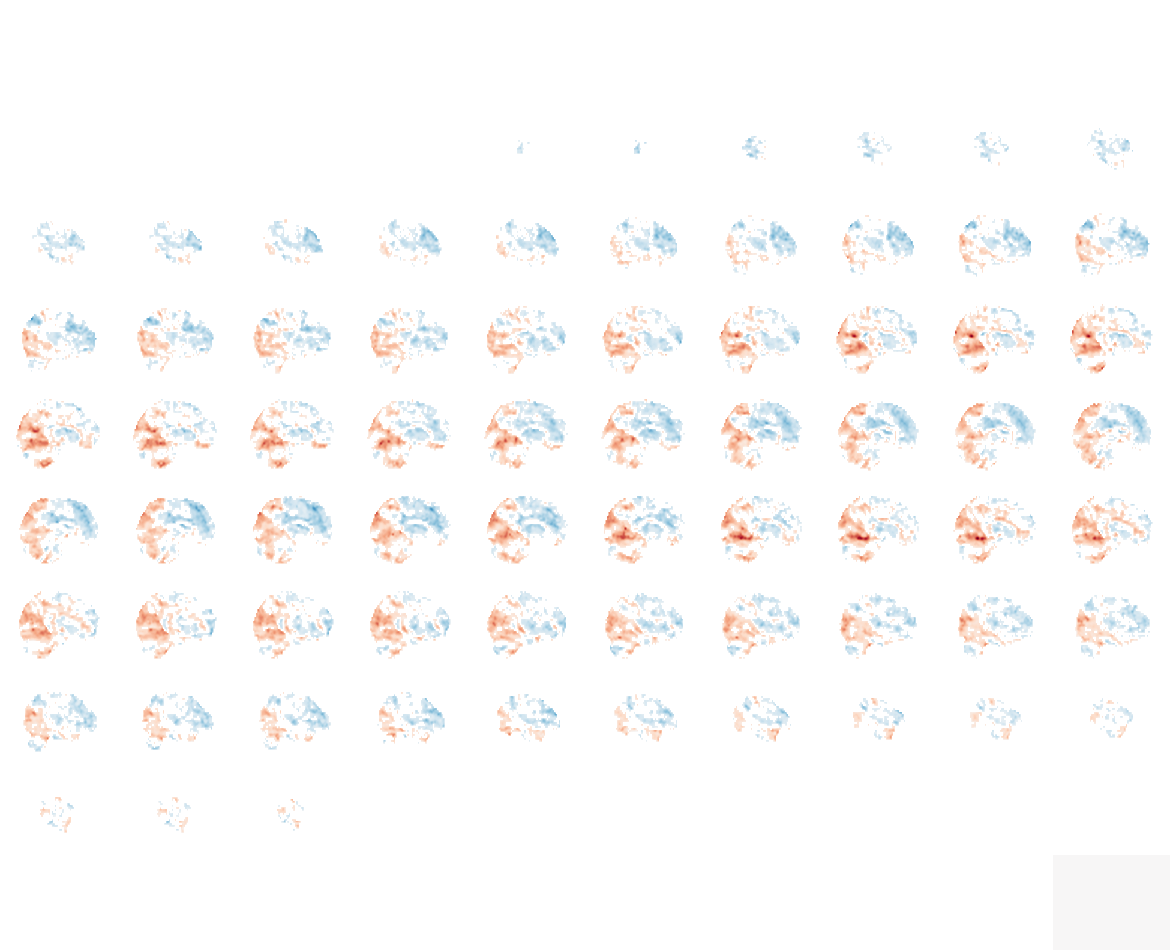

In [3]:

from nilearn import plotting 
tmap_path = '/Users/zach/2025_RA/matthias/final images/tmaps/sleep_tmap_group.nii.gz'

plotting.view_img(tmap_path, threshold=1)

In [13]:
import pandas as pd
df = pd.read_json("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/qc/run_inclusion/clean-with-fd-clamped-20260504-16221777904527.json", lines=True)

df[df["above_fd"] == "True"]

,subject,run,stage,excluded,eog_run_len,invalid_stages,above_fd
5,9,1,global,True,NaN,False,True
50,17,7,global,True,NaN,False,True
108,7,5,global,True,NaN,False,True
129,13,3,global,True,NaN,False,True
130,13,4,global,True,NaN,False,True
174,27,5,global,True,NaN,True,True
178,31,4,global,True,NaN,False,True
179,31,5,global,True,NaN,False,True
180,31,6,global,True,NaN,False,True
183,27,7,global,True,NaN,False,True


In [6]:
import numpy as np

data = np.load('/Volumes/NSD/sub-01_eyes/ses-nsd31/func/mask_sub-01_ses-nsd31_task-nsdcore_run-01_bold_mcf.p', allow_pickle=True)

# Reshape to 2D: (num_voxels, timepoints)
reshaped_data = data.reshape(-1, data.shape[-1])  # (voxels, timepoints)

# Remove voxels that are zero across all timepoints
nonzero_voxel_mask = ~(reshaped_data == 0).all(axis=1)
filtered_data = reshaped_data[nonzero_voxel_mask]

# Compute voxel-wise correlation across consecutive TRs
corrmat = np.corrcoef(
    filtered_data, rowvar=False
)  # Columns (TRs) represent variables to compute corr over

# Extract values just below the diagonal: elements at (i+1, i)
below_diagonal = corrmat[1:, :-1]
sub_diagonal_values = below_diagonal[
    np.arange(below_diagonal.shape[0]), np.arange(below_diagonal.shape[0])
]
dissimilarity = 1 - sub_diagonal_values

# Shift half TR to align with functional images
dissimilarity = 0.5 * (dissimilarity[:-1] + dissimilarity[1:])


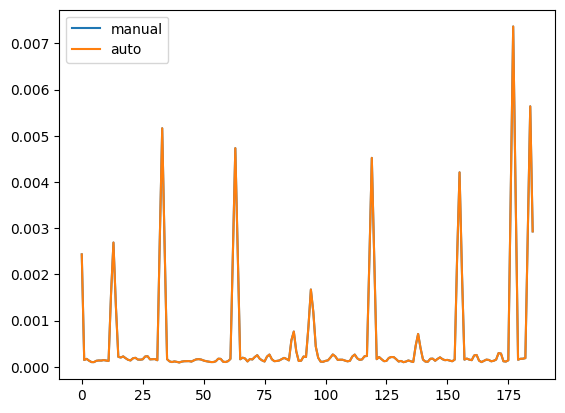

In [7]:
from matplotlib import pyplot as plt
other = np.load("/Volumes/NSD/derivatives/mreyemove1/sub-01/ses-nsd31/func/eye_move/sub-01_ses-nsd31_task-nsdcore_run-01_desc-mreyemove-timeseries.npy")
plt.plot(dissimilarity, label="manual")
plt.plot(other, label="auto")
plt.legend()